 My goal is to predict the length of patients' stays using the other factors in their "charts." To do this, I first need to collect and process the data from Kaggle, an online database.

In [1]:
#Importing relevant libraries
import kagglehub
import pandas as pd

#Downloading data from Kaggle
path = kagglehub.dataset_download("abdallaahmed77/healthcare-risk-factors-dataset")
print("Path to dataset files:", path)
df = pd.read_csv(path + "/dirty_v3_path.csv")

#Clearing out irrelevant info.
df = df.drop(['noise_col', 'random_notes'], axis=1)

#Verifying
display(df.head())

#Identifying columns with missing values
missing_values = df.isnull().sum()
print("Missing values before handling:")
print(missing_values[missing_values > 0])

#Imputing missing values
# For numerical columns, using the median (less sensitive to outliers than mean)
for col in ['Age', 'Glucose', 'Blood Pressure', 'BMI', 'Oxygen Saturation', 'Cholesterol', 'Triglycerides', 'HbA1c', 'Stress Level', 'Sleep Hours', 'LengthOfStay', 'Physical Activity']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

#For categorical columns, using the mode
for col in ['Gender', 'Medical Condition', 'Smoking', 'Alcohol', 'Diet Score', 'Family History']:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

print("\nMissing values after handling:")
print(df.isnull().sum())

#Identifing and encode categorical columns
categorical_cols = ['Gender', 'Medical Condition']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

display(df.head()) #Re-verifying

100%|██████████| 1.28M/1.28M [00:00<00:00, 24.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/abdallaahmed77/healthcare-risk-factors-dataset/versions/1


,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64


Missing values before handling:
Age                  4500
Gender               4500
Medical Condition    4500
Glucose              4500
Blood Pressure       4500
dtype: int64

Missing values after handling:
Age                  0
Gender               0
Medical Condition    0
Glucose              0
Blood Pressure       0
BMI                  0
Oxygen Saturation    0
LengthOfStay         0
Cholesterol          0
Triglycerides        0
HbA1c                0
Smoking              0
Alcohol              0
Physical Activity    0
Diet Score           0
Family History       0
Stress Level         0
Sleep Hours          0
dtype: int64


,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,...,Family History,Stress Level,Sleep Hours,Gender_Male,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Healthy,Medical Condition_Hypertension,Medical Condition_Obesity
0,46.0,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,...,0,5.07,6.05,True,False,False,True,False,False,False
1,22.0,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,...,0,5.87,7.72,True,False,False,False,True,False,False
2,50.0,95.24,138.32,22.53,90.31,2,214.94,165.35,5.60,0,...,1,3.09,4.82,False,True,False,False,False,False,False
3,57.0,110.50,130.53,38.47,96.60,5,197.71,182.13,6.92,0,...,0,3.01,5.33,False,False,False,False,False,False,True
4,66.0,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,...,0,6.38,6.64,False,False,False,False,False,True,False


Now that all the entries have values (welp), I need to figure out which features to include in the calculations. A correlation matrix will be helpful for identifying the necessary ones:

In [2]:
#Correlation matrix
correlation_matrix = df.corr(numeric_only=True)
print("Correlation matrix:")
display(correlation_matrix)

#...and correlation with length of stay
length_of_stay_correlation = correlation_matrix['LengthOfStay'].sort_values(ascending=False)
print("\nCorrelation with LengthOfStay:")
display(length_of_stay_correlation)

Correlation matrix:


,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,...,Family History,Stress Level,Sleep Hours,Gender_Male,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Healthy,Medical Condition_Hypertension,Medical Condition_Obesity
Age,1.000000,0.097917,0.275871,-0.010503,0.070988,0.101629,0.164014,0.101442,0.093721,0.056518,...,0.106087,0.156672,-0.076132,0.001309,-0.321038,0.007669,0.075223,-0.217549,0.279950,-0.224279
Glucose,0.097917,1.000000,0.045707,0.067845,-0.002839,0.209352,0.003495,0.061111,0.562167,-0.040540,...,0.139453,0.063563,-0.113760,-0.002156,-0.139106,-0.064841,0.650613,-0.215396,-0.145443,-0.155547
Blood Pressure,0.275871,0.045707,1.000000,0.066864,0.008573,0.034295,0.238906,0.171739,0.043548,0.107079,...,0.102522,0.203720,-0.138093,0.006225,-0.183999,-0.086129,-0.011892,-0.296939,0.418728,-0.097209
BMI,-0.010503,0.067845,0.066864,1.000000,0.066021,0.001351,0.131115,0.186505,0.125447,-0.002459,...,0.057824,-0.012055,-0.022468,-0.001184,-0.161674,-0.088594,0.056103,-0.268610,-0.035415,0.447666
Oxygen Saturation,0.070988,-0.002839,0.008573,0.066021,1.000000,-0.145913,-0.023322,-0.009648,-0.007675,-0.045577,...,-0.000745,-0.105826,0.167804,0.008348,-0.357194,-0.109543,0.001797,0.180064,0.006002,0.107255
LengthOfStay,0.101629,0.209352,0.034295,0.001351,-0.145913,1.000000,0.100028,0.080654,0.240723,0.094633,...,0.051304,0.264238,-0.253759,0.004313,-0.043067,0.640677,0.208545,-0.355274,-0.066462,-0.125580
Cholesterol,0.164014,0.003495,0.238906,0.131115,-0.023322,0.100028,1.000000,0.178466,0.025627,0.081800,...,0.075586,0.162524,-0.135107,0.006485,-0.097397,0.013360,-0.051424,-0.339382,0.250956,0.086726
Triglycerides,0.101442,0.061111,0.171739,0.186505,-0.009648,0.080654,0.178466,1.000000,0.089357,0.059926,...,0.065852,0.101146,-0.112659,0.001856,-0.089742,-0.024877,0.025602,-0.324077,0.120995,0.193518
HbA1c,0.093721,0.562167,0.043548,0.125447,-0.007675,0.240723,0.025627,0.089357,1.000000,-0.045991,...,0.150820,0.056337,-0.124423,-0.001294,-0.160227,-0.055719,0.678098,-0.279771,-0.177454,-0.083788
Smoking,0.056518,-0.040540,0.107079,-0.002459,-0.045577,0.094633,0.081800,0.059926,-0.045991,1.000000,...,0.017032,0.108368,-0.085964,-0.003136,0.018630,0.099374,-0.083169,-0.129260,0.144984,-0.033069



Correlation with LengthOfStay:


,LengthOfStay
LengthOfStay,1.000000
Medical Condition_Cancer,0.640677
Stress Level,0.264238
HbA1c,0.240723
Glucose,0.209352
Medical Condition_Diabetes,0.208545
Age,0.101629
Cholesterol,0.100028
Smoking,0.094633
Triglycerides,0.080654


I'm going to do a linear regression model, based on the correlation matrix implying linear relationships... and because we covered it in class, so I know what it does!

In [3]:
#Importing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#Defining features (X) and target (y)
X = df.drop('LengthOfStay', axis=1)
y = df['LengthOfStay']

#Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Instantiating a LinearRegression model
model = LinearRegression()

#Training the LinearRegression model
model.fit(X_train, y_train)

LinearRegression()

In [4]:
#Model evalation

#Importing
from sklearn.metrics import mean_squared_error, r2_score

#Predictions on the test set
y_pred = model.predict(X_test)

#Calculating the Mean Squared Error (MSE) (ouch)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")

#Calculating the R-squared score (also ouch)
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2) Score: {r2}")

Mean Squared Error (MSE): 3.2624804948888935
R-squared (R2) Score: 0.5758694153309581


That didn't work as well as I would have liked it do, but I'll try this model on the test data anyway.

,LengthOfStay
count,6000.000000
mean,0.000324
std,1.806384
min,-6.377348
25%,-1.263999
50%,-0.116218
75%,1.048218
max,14.658025


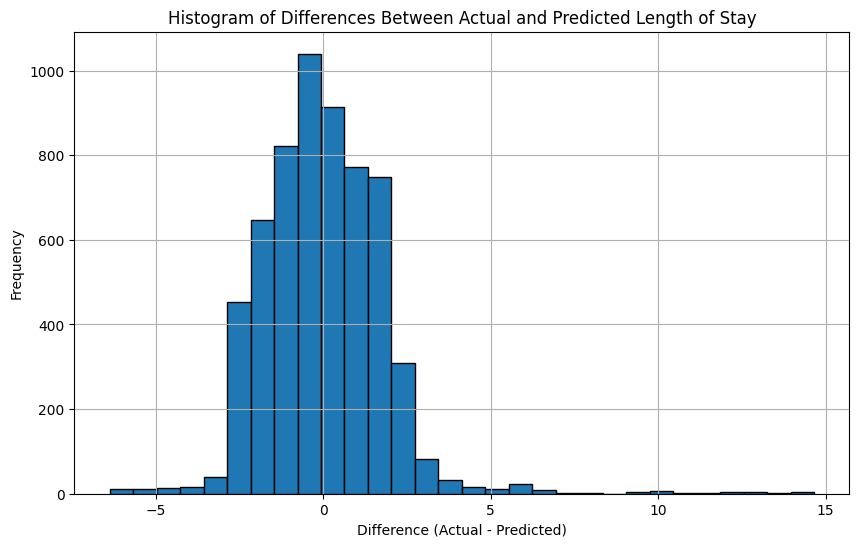

In [5]:
#Using trained model for predictions
predictions = model.predict(X_test)

#Calculating the difference between actual and predicted values
differences = y_test - predictions

#Displaying basic statistics of the differences using built-in "describe" (yay)
display(differences.describe())

#Aaand a histogram of the differences as one final touch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(differences, bins=30, edgecolor='black')
plt.title('Histogram of Differences Between Actual and Predicted Length of Stay')
plt.xlabel('Difference (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()